In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("student_final_marks_dataset.csv")
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
0,101,2,65,55,50,54
1,102,3,68,58,55,58
2,103,3,70,60,57,60
3,104,4,72,62,60,63
4,105,4,75,65,62,66


In [3]:
df.shape

(20, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        20 non-null     int64
 1   Study_Hours       20 non-null     int64
 2   Attendance        20 non-null     int64
 3   Assignment_Score  20 non-null     int64
 4   Previous_Marks    20 non-null     int64
 5   Final_Marks       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [5]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,110.50000,5.950000,81.750000,73.300000,70.900000,75.150000
std,5.91608,2.258901,8.848877,10.533655,11.317895,11.979258
min,101.00000,2.000000,65.000000,55.000000,50.000000,54.000000
25%,105.75000,4.000000,75.750000,65.750000,63.500000,66.750000
50%,110.50000,6.000000,82.500000,72.500000,70.500000,74.500000
75%,115.25000,8.000000,89.250000,82.500000,80.500000,85.500000
max,120.00000,10.000000,95.000000,90.000000,90.000000,95.000000


In [6]:
df.isnull().sum()

Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Previous_Marks      0
Final_Marks         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        20 non-null     int64
 1   Study_Hours       20 non-null     int64
 2   Attendance        20 non-null     int64
 3   Assignment_Score  20 non-null     int64
 4   Previous_Marks    20 non-null     int64
 5   Final_Marks       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [10]:
x=df.drop(["Student_ID","Final_Marks"],axis=1)
y=df["Final_Marks"]
x

,Study_Hours,Attendance,Assignment_Score,Previous_Marks
0,2,65,55,50
1,3,68,58,55
2,3,70,60,57
3,4,72,62,60
4,4,75,65,62
5,5,78,68,65
6,5,80,70,67
7,6,82,72,70
8,6,84,75,72
9,7,85,78,75


In [11]:
y

0     54
1     58
2     60
3     63
4     66
5     69
6     71
7     74
8     77
9     80
10    82
11    85
12    87
13    90
14    92
15    95
16    67
17    75
18    70
19    88
Name: Final_Marks, dtype: int64

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,Study_Hours,Attendance,Assignment_Score,Previous_Marks
8,6,84,75,72
5,5,78,68,65
11,8,89,82,80
3,4,72,62,60
18,5,79,69,66
16,4,76,66,64
13,9,92,86,85
2,3,70,60,57
9,7,85,78,75
19,8,91,85,83


In [13]:
x_test

,Study_Hours,Attendance,Assignment_Score,Previous_Marks
0,2,65,55,50
17,6,83,73,71
15,10,95,90,90
1,3,68,58,55


In [14]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred=model.predict(x_test)
y_pred

array([53.622443  , 75.09441196, 94.8244838 , 58.00096145])

In [16]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison

,Actual,Predicted
0,54,53.622443
17,75,75.094412
15,95,94.824484
1,58,58.000961


In [17]:
model.coef_

array([0.36908908, 0.05100292, 0.53344325, 0.45121817])

In [18]:
model.intercept_

np.float64(-2.3312122105377)

In [19]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
0,101,2,65,55,50,54
1,102,3,68,58,55,58
2,103,3,70,60,57,60
3,104,4,72,62,60,63
4,105,4,75,65,62,66


In [20]:
coef =pd.DataFrame({
    "Features" : x.columns,
    "Coefficients": model.coef_
})
coef

,Features,Coefficients
0,Study_Hours,0.369089
1,Attendance,0.051003
2,Assignment_Score,0.533443
3,Previous_Marks,0.451218


In [21]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [22]:
mean_absolute_error(y_test,y_pred)

0.1621116511509939

In [23]:
mean_squared_error(y_test,y_pred)

0.045567441878415084

In [24]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.213465317741349)

In [25]:
r2_score(y_test,y_pred)

0.9998262442635714

In [26]:
new_student=[[6,90,85,88]]
prediction=model.predict(new_student)
prediction

c:\Users\kanan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([89.52346032])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        20 non-null     int64
 1   Study_Hours       20 non-null     int64
 2   Attendance        20 non-null     int64
 3   Assignment_Score  20 non-null     int64
 4   Previous_Marks    20 non-null     int64
 5   Final_Marks       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


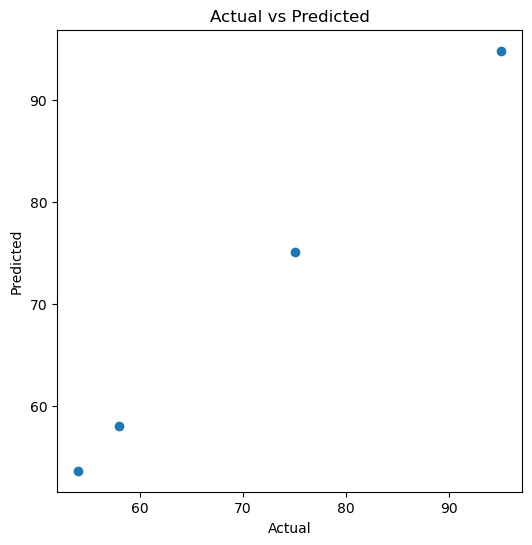

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [29]:
#save file to save train model so that everone can use 

import joblib
joblib.dump(model,"student_marks_model.pkl")

['student_marks_model.pkl']

In [30]:
df_model=joblib.load("student_marks_model.pkl")


In [31]:
df_model.predict([[6,90,85,88]])

c:\Users\kanan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([89.52346032])

In [32]:
#DEcision tree concept
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [33]:
df1 = pd.read_csv("student_decision_tree.csv")
df1.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1


In [34]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      30 non-null     int64
 1   Study_Hours     30 non-null     int64
 2   Attendance      30 non-null     int64
 3   Assignments     30 non-null     int64
 4   Previous_Marks  30 non-null     int64
 5   Discipline      30 non-null     int64
 6   Pass            30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [35]:
df1.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,115.500000,4.466667,72.500000,65.666667,63.000000,73.166667,0.566667
std,8.803408,2.129163,12.851271,12.507469,12.752282,10.248914,0.504007
min,101.000000,1.000000,48.000000,40.000000,38.000000,50.000000,0.000000
25%,108.250000,3.000000,62.250000,55.500000,52.500000,66.500000,0.000000
50%,115.500000,4.500000,73.500000,66.500000,64.000000,74.500000,1.000000
75%,122.750000,6.000000,81.750000,74.750000,71.750000,80.000000,1.000000
max,130.000000,8.000000,94.000000,88.000000,86.000000,91.000000,1.000000


In [36]:
df1.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Discipline        0
Pass              0
dtype: int64

In [37]:
df1.duplicated().sum()

np.int64(0)

In [38]:
df1.shape

(30, 7)

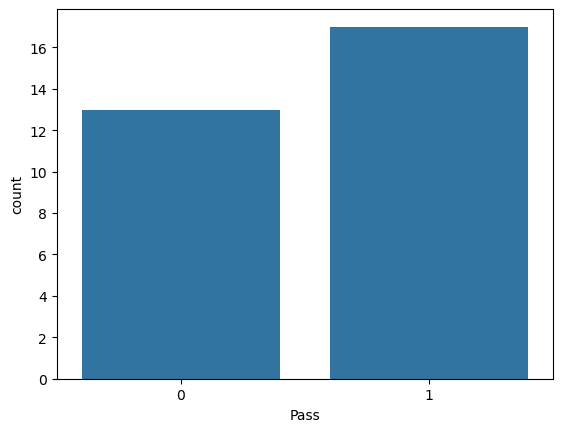

In [39]:
sns.countplot(data=df1, x="Pass")
plt.show()


In [40]:
model.coef_

array([0.36908908, 0.05100292, 0.53344325, 0.45121817])

In [41]:
df.corr(numeric_only=True)

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
Student_ID,1.000000,0.667552,0.720345,0.698456,0.705081,0.696974
Study_Hours,0.667552,1.000000,0.986740,0.991606,0.994125,0.994186
Attendance,0.720345,0.986740,1.000000,0.995760,0.994554,0.995379
Assignment_Score,0.698456,0.991606,0.995760,1.000000,0.997988,0.999407
Previous_Marks,0.705081,0.994125,0.994554,0.997988,1.000000,0.999332
Final_Marks,0.696974,0.994186,0.995379,0.999407,0.999332,1.000000


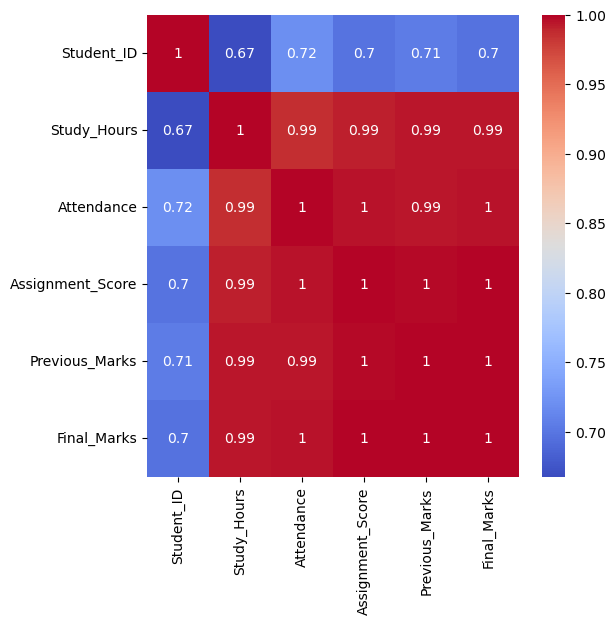

In [42]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [43]:
x=df1.drop(["Student_ID","Pass"],axis=1)
y=df1["Pass"]
x

,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline
0,2,60,55,50,65
1,3,65,58,55,70
2,4,70,60,60,72
3,5,75,68,65,75
4,6,80,72,70,80
5,7,85,78,75,82
6,8,90,82,80,85
7,2,55,50,48,60
8,3,68,62,58,68
9,4,72,65,63,74


In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [45]:
x_train

,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline
28,2,59,54,50,63
24,5,77,71,68,78
12,7,88,80,78,84
0,2,60,55,50,65
4,6,80,72,70,80
16,4,69,63,60,71
5,7,85,78,75,82
13,1,50,45,42,55
11,6,82,75,72,79
22,3,62,55,52,66


In [46]:
x_test.shape

(6, 5)

In [47]:
model= DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 1])

In [49]:
accuracy_score(y_test,y_pred)

0.8333333333333334

In [50]:
confusion_matrix(y_test,y_pred)

array([[2, 0],
       [1, 3]])

In [51]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison   

,Actual,Predicted
27,1,1
15,0,0
23,1,0
17,1,1
8,0,0
9,1,1
